<a href="https://colab.research.google.com/github/Vivek-afk81/finance-ml-stock-direction/blob/main/stock_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [61]:
from google.colab import drive
drive.mount("/content/drive")

In [62]:
import os
os.chdir("/content/drive/My Drive/finance-ml-stock-direction")

##This is a small-scale implementation of a price movement prediction workflow, focusing on data preprocessing, return calculation, and target generation.

In [82]:
# Step 1: Import libraries
import pandas as pd

# Step 2: Create example price data
data = {
    "price": [100, 102, 101, 103, 104, 102]
}

df = pd.DataFrame(data)

# Step 3: Create daily returns
df["return"] = df["price"].pct_change()

# Step 4: Create future return (label source)
df["future_return"] = df["return"].shift(-1)

# Step 5: Drop rows with missing values
# (first row: no return, last row: no future return)
df = df.dropna()

# Step 6: Create target (1 = up, 0 = down)
df["target"] = (df["future_return"] > 0).astype(int)

# Optional: drop helper column
df = df.drop(columns=["future_return"])

# Step 7: Final result
print(df)


   price    return  target
1    102  0.020000       0
2    101 -0.009804       1
3    103  0.019802       1
4    104  0.009709       0


#Import necessary libraries


In [121]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

#EXPLORATORY DATA ANALYSIS(EDA) FOR STOCK MARKET DATA

###STEP 1:

Load and understand the raw financial data

In [84]:
import yfinance as yf

df_aapl=yf.download("AAPL",start="2020-01-01",end="2025-01-01")
msft = yf.download("MSFT", start="2020-01-01", end="2025-01-01")


/tmp/ipython-input-4236495162.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_aapl=yf.download("AAPL",start="2020-01-01",end="2025-01-01")
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-4236495162.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  msft = yf.download("MSFT", start="2020-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


In [85]:
df_aapl.head(),df_aapl.tail()

(Price           Close       High        Low       Open     Volume
 Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
 Date                                                             
 2020-01-02  72.468269  72.528589  71.223267  71.476607  135480400
 2020-01-03  71.763733  72.523762  71.539345  71.696175  146322800
 2020-01-06  72.335541  72.374146  70.634524  70.885457  118387200
 2020-01-07  71.995354  72.600960  71.775789  72.345204  108872000
 2020-01-08  73.153496  73.455095  71.698581  71.698581  132079200,
 Price            Close        High         Low        Open    Volume
 Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
 Date                                                                
 2024-12-24  257.037506  257.047440  254.140589  254.339701  23234700
 2024-12-26  257.853760  258.928914  256.470034  257.027510  27237100
 2024-12-27  254.439224  257.535238  251.920617  256.669129  42355300
 2024-12-30  251.064484  252.358634  249.62

In [86]:
msft.head(),msft.tail()

(Price            Close        High         Low        Open    Volume
 Ticker            MSFT        MSFT        MSFT        MSFT      MSFT
 Date                                                                
 2020-01-02  152.505661  152.610105  150.331356  150.758619  22622100
 2020-01-03  150.606735  151.869547  150.075028  150.321902  21116200
 2020-01-06  150.996033  151.062503  148.603335  149.144547  20813700
 2020-01-07  149.619293  151.603706  149.372433  151.271396  21634100
 2020-01-08  152.002426  152.676564  149.970537  150.901025  27746500,
 Price            Close        High         Low        Open    Volume
 Ticker            MSFT        MSFT        MSFT        MSFT      MSFT
 Date                                                                
 2024-12-24  436.112885  436.380927  431.010539  431.467162   7164500
 2024-12-26  434.901794  437.711088  433.432652  435.864693   8194200
 2024-12-27  427.377350  432.033009  423.227966  431.417554  18117700
 2024-12-30  421.71

In [87]:
len(df_aapl)

1258

In [88]:
len(msft)

1258

In [89]:
df_aapl.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03
mean,151.659030,153.183637,149.958963,151.504427,9.057103e+07
std,41.929755,42.070380,41.706645,41.873456,5.324438e+07
min,54.264343,55.263193,51.420164,55.161616,2.323470e+07
25%,126.513731,127.633788,124.509412,125.957970,5.546825e+07
50%,150.247238,151.991609,148.312224,150.067177,7.628335e+07
75%,176.228840,177.782103,174.661136,176.034665,1.077425e+08
max,257.853760,258.928914,256.470034,257.027510,4.265100e+08


In [90]:
df_aapl.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1258 non-null   float64
 1   (High, AAPL)    1258 non-null   float64
 2   (Low, AAPL)     1258 non-null   float64
 3   (Open, AAPL)    1258 non-null   float64
 4   (Volume, AAPL)  1258 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 59.0 KB


- (Close, AAPL) → The closing price of Apple stock each day.
- (High, AAPL) → The highest price reached during that trading day.
- (Low, AAPL) → The lowest price reached during that trading day.
- (Open, AAPL) → The opening price at the start of the trading day.
- (Volume, AAPL) → The number of shares traded that day.


In [91]:
df_aapl

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.468269,72.528589,71.223267,71.476607,135480400
2020-01-03,71.763733,72.523762,71.539345,71.696175,146322800
2020-01-06,72.335541,72.374146,70.634524,70.885457,118387200
2020-01-07,71.995354,72.600960,71.775789,72.345204,108872000
2020-01-08,73.153496,73.455095,71.698581,71.698581,132079200
...,...,...,...,...,...
2024-12-24,257.037506,257.047440,254.140589,254.339701,23234700
2024-12-26,257.853760,258.928914,256.470034,257.027510,27237100


In [92]:
df_aapl.columns=df_aapl.columns.droplevel('Ticker')
df_aapl

Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,72.468269,72.528589,71.223267,71.476607,135480400
2020-01-03,71.763733,72.523762,71.539345,71.696175,146322800
2020-01-06,72.335541,72.374146,70.634524,70.885457,118387200
2020-01-07,71.995354,72.600960,71.775789,72.345204,108872000
2020-01-08,73.153496,73.455095,71.698581,71.698581,132079200
...,...,...,...,...,...
2024-12-24,257.037506,257.047440,254.140589,254.339701,23234700
2024-12-26,257.853760,258.928914,256.470034,257.027510,27237100
2024-12-27,254.439224,257.535238,251.920617,256.669129,42355300


###Create daily returns

In [93]:
df_aapl["return"]=df_aapl["Close"].pct_change()
df_aapl.tail()

Price,Close,High,Low,Open,Volume,return
Date,,,,,,
2024-12-24,257.037506,257.047440,254.140589,254.339701,23234700,0.011478
2024-12-26,257.853760,258.928914,256.470034,257.027510,27237100,0.003176
2024-12-27,254.439224,257.535238,251.920617,256.669129,42355300,-0.013242
2024-12-30,251.064484,252.358634,249.621015,251.094347,35557500,-0.013263
2024-12-31,249.292496,252.139619,248.306948,251.303405,39480700,-0.007058


Create the targets
- 1 if tomorrow’s return > 0
- 0 otherwise


(Remember the shift.)



In [94]:
df_aapl["future_return"] = df_aapl["return"].shift(-1)
df_aapl=df_aapl.dropna()
df_aapl["target"] = (df_aapl["future_return"] > 0).astype(int)
df_aapl = df_aapl.drop(columns=["future_return"])


/tmp/ipython-input-49599929.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_aapl["target"] = (df_aapl["future_return"] > 0).astype(int)


In [95]:
df_aapl.tail()

Price,Close,High,Low,Open,Volume,return,target
Date,,,,,,,
2024-12-23,254.120697,254.498976,252.308884,253.622948,40858800,0.003065,1
2024-12-24,257.037506,257.047440,254.140589,254.339701,23234700,0.011478,1
2024-12-26,257.853760,258.928914,256.470034,257.027510,27237100,0.003176,0
2024-12-27,254.439224,257.535238,251.920617,256.669129,42355300,-0.013242,0
2024-12-30,251.064484,252.358634,249.621015,251.094347,35557500,-0.013263,0


In [98]:
df_aapl.describe()

Price,Close,High,Low,Open,Volume,return,target
count,1256.000000,1256.000000,1256.000000,1256.000000,1.256000e+03,1256.000000,1256.000000
mean,151.644346,153.169067,149.943348,151.488686,9.057596e+07,0.001189,0.533439
std,41.812839,41.949388,41.588091,41.750941,5.325218e+07,0.019962,0.499079
min,54.264343,55.263193,51.420164,55.161616,2.323470e+07,-0.128647,0.000000
25%,126.572321,127.759479,124.597013,125.957981,5.546915e+07,-0.008426,0.000000
50%,150.247238,151.991609,148.312224,150.067177,7.628335e+07,0.001210,1.000000
75%,176.124966,177.777154,174.647097,175.957973,1.077074e+08,0.012017,1.000000
max,257.853760,258.928914,256.470034,257.027510,4.265100e+08,0.119808,1.000000


In [99]:
df_aapl.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1256 entries, 2020-01-03 to 2024-12-30
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1256 non-null   float64
 1   High    1256 non-null   float64
 2   Low     1256 non-null   float64
 3   Open    1256 non-null   float64
 4   Volume  1256 non-null   int64  
 5   return  1256 non-null   float64
 6   target  1256 non-null   int64  
dtypes: float64(5), int64(2)
memory usage: 78.5 KB


1. P-value (Statistical Hypothesis Testing)
- What it is: A p-value measures how likely your observed data would occur if the null hypothesis were true.
- Intuition: Imagine you flip a coin 100 times and get 70 heads. If the coin were fair, that outcome is pretty unlikely. The p-value quantifies that “unlikeliness.”


- If p_val < 0.05, you reject the null → Apple’s returns are not just random noise, there’s a statistically significant drift.
- If p_val > 0.05, you can’t reject the null → returns look like noise around zero.


 Important: A p-value does not tell you the probability the hypothesis is true. It’s about the probability of the data given the hypothesis.


In [100]:
from scipy import stats

# exaple daily returns already in df['return']
#null hypothesis: mean return =0

t_stat,p_val=stats.ttest_1samp(df['return'],0)
print("t-statistic:", t_stat)
print("p-value:", p_val)


t-statistic: 1.4176931096204235
p-value: 0.2512964867802692


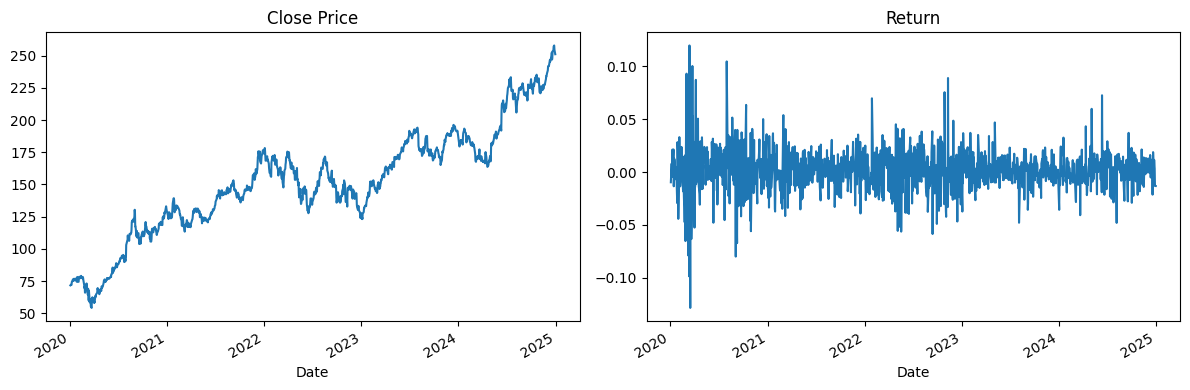

In [108]:
fig,axes=plt.subplots(1, 2, figsize=(12, 4))
df_aapl["Close"].plot(ax=axes[0], title="Close Price")
df_aapl["return"].plot(ax=axes[1], title="Return")

plt.tight_layout()
plt.show()

Returns are more stable than prices because prices are non-stationary and exhibit trends and scale dependence, whereas returns normalize price changes and tend to have a constant mean and variance. This can be verified visually through rolling statistics and formally using stationarity tests such as the Augmented Dickey–Fuller test, which typically rejects non-stationarity for returns but not for prices.

###Distribution of Returns

Analyze the distribution of daily returns using a histogram to check for normality, skewness, and kurtosis (fat tails).

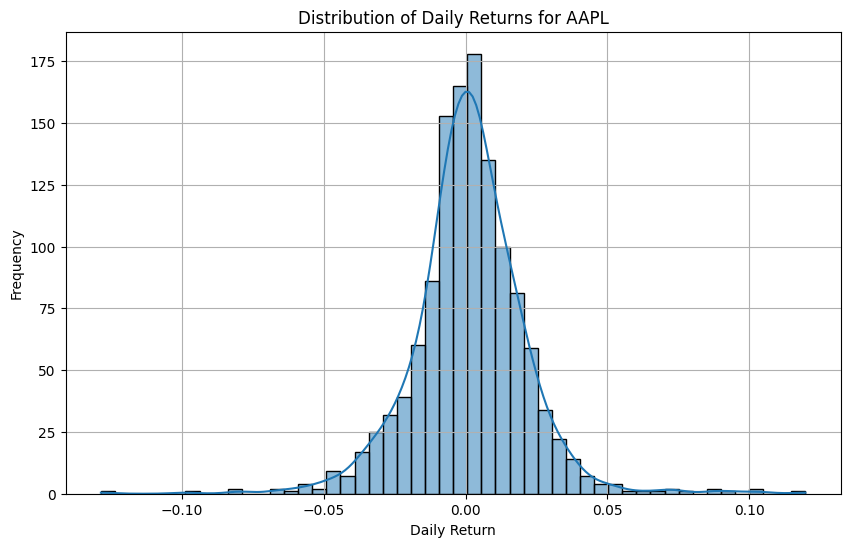

In [109]:
plt.figure(figsize=(10, 6))
sns.histplot(df_aapl['return'].dropna(), bins=50, kde=True)
plt.title('Distribution of Daily Returns for AAPL')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

###Autocorrelation of Returns

 Examine the autocorrelation of returns to see if past returns can predict future returns. This is crucial for understanding if the series is predictable.

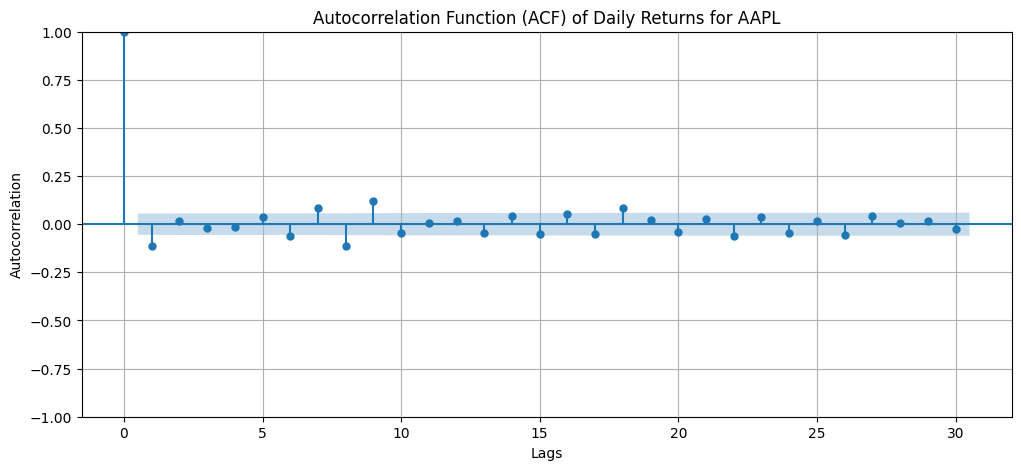

In [110]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(12, 5))
plot_acf(df_aapl['return'].dropna(), lags=30, ax=plt.gca())
plt.title('Autocorrelation Function (ACF) of Daily Returns for AAPL')
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.show()

##Clear Baseline model

Is my ML model better than a dumb guess?

In [111]:
# Naive base line : tomorrow same as today

df_aapl["baseline_pred"]=(df_aapl["return"]>0).astype(int)

baseline_accuracy=(
    df_aapl["baseline_pred"]==df_aapl["target"]
).mean()

print("Baseline accuracy: ",baseline_accuracy)

Baseline accuracy:  0.4888535031847134


##Rolling Features

For each day:

- Look back N days

- Summarize behavior

- Use that summary as a clue

In [112]:
# Rolling features
df_aapl["ret_mean_5"] = df_aapl["return"].rolling(5).mean()
df_aapl["ret_std_5"]  = df_aapl["return"].rolling(5).std()

df_aapl["ret_mean_10"] = df_aapl["return"].rolling(10).mean()
df_aapl["ret_std_10"]  = df_aapl["return"].rolling(10).std()

In [113]:
df_aapl

Price,Close,High,Low,Open,Volume,return,target,baseline_pred,ret_mean_5,ret_std_5,ret_mean_10,ret_std_10
Date,,,,,,,,,,,,
2020-01-03,71.763733,72.523762,71.539345,71.696175,146322800,-0.009722,1,0,NaN,NaN,NaN,NaN
2020-01-06,72.335541,72.374146,70.634524,70.885457,118387200,0.007968,0,1,NaN,NaN,NaN,NaN
2020-01-07,71.995354,72.600960,71.775789,72.345204,108872000,-0.004703,1,0,NaN,NaN,NaN,NaN
2020-01-08,73.153496,73.455095,71.698581,71.698581,132079200,0.016086,1,1,NaN,NaN,NaN,NaN
2020-01-09,74.707336,74.900357,73.879750,74.130675,170108400,0.021241,1,1,0.006174,0.013224,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-23,254.120697,254.498976,252.308884,253.622948,40858800,0.003065,1,1,0.003439,0.015057,0.003454,0.010873
2024-12-24,257.037506,257.047440,254.140589,254.339701,23234700,0.011478,1,1,0.003790,0.015260,0.004188,0.011168
2024-12-26,257.853760,258.928914,256.470034,257.027510,27237100,0.003176,0,1,0.008710,0.006617,0.005022,0.010694


In [115]:
df_aapl = df_aapl.dropna()
df_aapl

Price,Close,High,Low,Open,Volume,return,target,baseline_pred,ret_mean_5,ret_std_5,ret_mean_10,ret_std_10
Date,,,,,,,,,,,,
2020-01-16,76.060905,76.171899,75.300877,75.662796,108829200,0.012526,1,1,0.003673,0.013709,0.004923,0.012766
2020-01-17,76.902977,76.905385,76.003002,76.309424,137816400,0.011071,0,1,0.005435,0.014044,0.007003,0.011771
2020-01-21,76.381821,76.972951,76.244290,76.531413,110843200,-0.006777,1,0,-0.000194,0.011466,0.005528,0.012535
2020-01-22,76.654449,77.206974,76.560347,76.866769,101832400,0.003569,1,1,0.003221,0.008727,0.006355,0.012048
2020-01-23,77.023613,77.103232,76.159829,76.707538,104472000,0.004816,0,1,0.005041,0.007653,0.005228,0.011554
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-23,254.120697,254.498976,252.308884,253.622948,40858800,0.003065,1,1,0.003439,0.015057,0.003454,0.010873
2024-12-24,257.037506,257.047440,254.140589,254.339701,23234700,0.011478,1,1,0.003790,0.015260,0.004188,0.011168
2024-12-26,257.853760,258.928914,256.470034,257.027510,27237100,0.003176,0,1,0.008710,0.006617,0.005022,0.010694


##Splitting the data into training and testing data

In [116]:
split_date="2023-01-01"

train= df_aapl[df_aapl.index<split_date]
test= df_aapl[df_aapl.index>= split_date]

features=[
    "ret_mean_5", "ret_std_5", "ret_mean_10", "ret_std_10"
]

X_train = train[features]
y_train=train["target"]

X_test=test[features]
y_test=test["target"]

##Training the ML model

In [123]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

model =LogisticRegression()
model.fit(X_train,y_train)

preds =model.predict(X_test)
print("Accuracy Logistic Regression:", accuracy_score(y_test, preds))
print("ROC-AUC Logistic Regression:", roc_auc_score(y_test, preds))



Accuracy Logistic Regression: 0.562874251497006
ROC-AUC Logistic Regression: 0.5


In [120]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)
print("XGBoost Accuracy:",accuracy_score(y_test, xgb_preds))
print("XGBoost ROC-AUC:",roc_auc_score(y_test, xgb_preds))

XGBoost Accuracy: 0.48902195608782434
XGBoost ROC-AUC: 0.470611094918877


### Key Findings
- Returns are more stable than prices and suitable for modeling.
- Naive baseline accuracy was ~0.4888%.
- Logistic regression achieved ~0.56287%, modestly outperforming baseline.
- XG Boost achieved ~ 0.48902%
- Results confirm market noisiness; small edges matter.
